
# Bootstrap confidence intervals: numerical experiments

This notebook reproduces the numerical experiments used in the lecture slides on bootstrap confidence intervals.

The main example is the mouse survival data from Efron and Tibshirani. We compute:

- the treatment--control mean difference;
- the treatment--control median difference;
- bootstrap standard errors;
- normal-based bootstrap confidence intervals;
- percentile bootstrap confidence intervals;
- bootstrap histograms.

The bootstrap uses a two-sample resampling scheme: treatment observations are resampled from the treatment group, and control observations are resampled from the control group.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## Mouse data

The response is survival time in days after surgery.


In [2]:

treatment = np.array([94, 197, 16, 38, 99, 141, 23], dtype=float)
control = np.array([52, 104, 146, 10, 51, 30, 40, 27, 46], dtype=float)

mouse_data = pd.DataFrame({
    "group": ["treatment"] * len(treatment) + ["control"] * len(control),
    "survival_days": np.r_[treatment, control],
})
mouse_data


,group,survival_days
0,treatment,94.0
1,treatment,197.0
2,treatment,16.0
3,treatment,38.0
4,treatment,99.0
5,treatment,141.0
6,treatment,23.0
7,control,52.0
8,control,104.0
9,control,146.0



## Statistics

We use two estimates of the treatment effect:
\[
\widehat\theta_{\rm mean} = \bar X - \bar Y,
\qquad
\widehat\theta_{\rm median} = {\rm median}(X)-{\rm median}(Y).
\]


In [3]:

def mean_difference(x, y):
    return np.mean(x) - np.mean(y)

def median_difference(x, y):
    return np.median(x) - np.median(y)

theta_hat_mean = mean_difference(treatment, control)
theta_hat_median = median_difference(treatment, control)

theta_hat_mean, theta_hat_median


(30.63492063492064, 48.0)


## Two-sample bootstrap

The two groups are kept separate. This corresponds to two unknown population distributions:
\[
F_{\rm trt},\qquad F_{\rm ctrl}.
\]
Pooling the observations would estimate one common distribution. That is a different statistical question.


In [4]:

def two_sample_bootstrap_replicates(x, y, statistic, B=5000, seed=123):
    """
    Generate two-sample bootstrap replications.

    Parameters
    ----------
    x, y : array-like
        Observations in the two groups.
    statistic : callable
        Function of two arrays, statistic(x_star, y_star).
    B : int
        Number of bootstrap replications.
    seed : int
        Random seed.

    Returns
    -------
    reps : np.ndarray
        Bootstrap replications.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    rng = np.random.default_rng(seed)

    reps = np.empty(B)
    for b in range(B):
        x_star = rng.choice(x, size=len(x), replace=True)
        y_star = rng.choice(y, size=len(y), replace=True)
        reps[b] = statistic(x_star, y_star)
    return reps

B = 5000
seed = 123

mean_reps = two_sample_bootstrap_replicates(
    treatment, control, mean_difference, B=B, seed=seed
)

median_reps = two_sample_bootstrap_replicates(
    treatment, control, median_difference, B=B, seed=seed
)



## Bootstrap standard errors and intervals

The bootstrap standard error is the sample standard deviation of the bootstrap replications:
\[
\widehat{\rm se}_B(\widehat\theta)
=
\left\{
\frac{1}{B-1}\sum_{b=1}^B
(\widehat\theta^{*(b)}-\overline{\theta}^{*})^2
\right\}^{1/2}.
\]

The normal-based interval is
\[
\widehat\theta \pm 1.96\,\widehat{\rm se}_B(\widehat\theta).
\]

The percentile interval is
\[
[\widehat q^*_{0.025},\widehat q^*_{0.975}],
\]
where the endpoints are empirical quantiles of the bootstrap replications.


In [5]:

def bootstrap_summary(theta_hat, reps, alpha=0.05):
    se = np.std(reps, ddof=1)
    z = 1.96
    normal = (theta_hat - z * se, theta_hat + z * se)
    percentile = tuple(np.quantile(reps, [alpha / 2, 1 - alpha / 2]))
    return {
        "Estimate": theta_hat,
        "Bootstrap SE": se,
        "Normal CI lower": normal[0],
        "Normal CI upper": normal[1],
        "Percentile CI lower": percentile[0],
        "Percentile CI upper": percentile[1],
    }

summary = pd.DataFrame(
    {
        "Mean difference": bootstrap_summary(theta_hat_mean, mean_reps),
        "Median difference": bootstrap_summary(theta_hat_median, median_reps),
    }
).T

summary.round(2)


,Estimate,Bootstrap SE,Normal CI lower,Normal CI upper,Percentile CI lower,Percentile CI upper
Mean difference,30.63,26.64,-21.57,82.84,-19.78,82.81
Median difference,48.00,39.85,-30.11,126.11,-29.00,101.00



These values should match the table in the slides, up to rounding.



## Bootstrap histograms


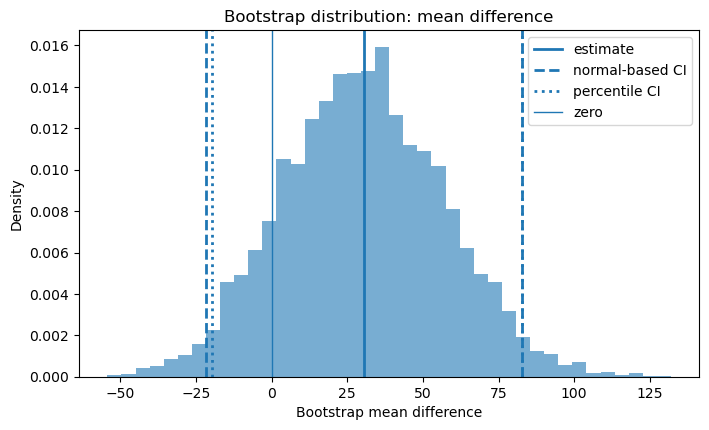

In [6]:

def plot_bootstrap_histogram(reps, theta_hat, title, xlabel):
    se = np.std(reps, ddof=1)
    normal_lo = theta_hat - 1.96 * se
    normal_hi = theta_hat + 1.96 * se
    perc_lo, perc_hi = np.quantile(reps, [0.025, 0.975])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(reps, bins=40, density=True, alpha=0.6)
    ax.axvline(theta_hat, linewidth=2, label="estimate")
    ax.axvline(normal_lo, linestyle="--", linewidth=2, label="normal-based CI")
    ax.axvline(normal_hi, linestyle="--", linewidth=2)
    ax.axvline(perc_lo, linestyle=":", linewidth=2, label="percentile CI")
    ax.axvline(perc_hi, linestyle=":", linewidth=2)
    ax.axvline(0, linewidth=1, label="zero")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()

plot_bootstrap_histogram(
    mean_reps,
    theta_hat_mean,
    "Bootstrap distribution: mean difference",
    "Bootstrap mean difference",
)


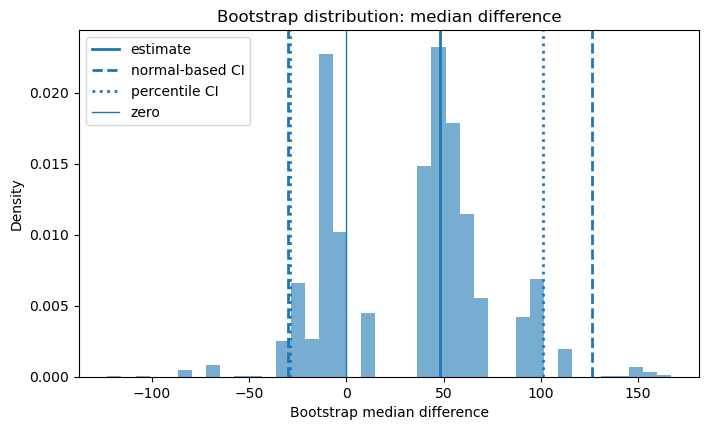

In [7]:

plot_bootstrap_histogram(
    median_reps,
    theta_hat_median,
    "Bootstrap distribution: median difference",
    "Bootstrap median difference",
)



## Interpretation

Both point estimates are positive. However, both 95% intervals include zero.

Thus the data are compatible with a positive treatment effect, but they do not estimate it precisely. The median difference is larger than the mean difference, but its bootstrap distribution is more variable and more discrete.



## Monte Carlo stability

The number of bootstrap replications controls simulation error, not sampling error in the original data. The following cell recomputes the intervals for several values of \(B\).


In [8]:

def run_for_B_values(B_values, statistic, theta_hat, seed=123):
    rows = []
    for B_current in B_values:
        reps = two_sample_bootstrap_replicates(
            treatment, control, statistic, B=B_current, seed=seed
        )
        out = bootstrap_summary(theta_hat, reps)
        out["B"] = B_current
        rows.append(out)
    return pd.DataFrame(rows).set_index("B")

B_values = [200, 500, 1000, 2000, 5000]

mean_stability = run_for_B_values(B_values, mean_difference, theta_hat_mean)
median_stability = run_for_B_values(B_values, median_difference, theta_hat_median)

mean_stability.round(2)


,Estimate,Bootstrap SE,Normal CI lower,Normal CI upper,Percentile CI lower,Percentile CI upper
B,,,,,,
200,30.63,28.34,-24.92,86.19,-32.42,80.25
500,30.63,27.98,-24.20,85.47,-27.72,83.54
1000,30.63,27.33,-22.93,84.20,-23.24,83.65
2000,30.63,26.54,-21.39,82.66,-18.45,83.48
5000,30.63,26.64,-21.57,82.84,-19.78,82.81


In [9]:

median_stability.round(2)


,Estimate,Bootstrap SE,Normal CI lower,Normal CI upper,Percentile CI lower,Percentile CI upper
B,,,,,,
200,48.0,43.16,-36.60,132.60,-66.0,111.0
500,48.0,41.39,-33.13,129.13,-29.0,111.0
1000,48.0,40.96,-32.28,128.28,-29.0,101.0
2000,48.0,39.98,-30.36,126.36,-29.0,101.0
5000,48.0,39.85,-30.11,126.11,-29.0,101.0



## Notes

1. The random seed is fixed only to make the classroom output reproducible.
2. The resampling scheme is part of the statistical model. Here it is a two-sample nonparametric bootstrap.
3. For reported confidence intervals, it is good practice to check that the endpoints are stable when \(B\) is increased.
